In [217]:
!pip install pandas scikit-learn underthesea
!pip install matplotlib seaborn


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl (8.2 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.3 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.3 MB 1.5 MB/s eta 0:00:02
   ----------------- ---------------------- 1.0/2.3 MB


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [218]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from underthesea import word_tokenize

In [219]:
df = pd.read_csv('Data_mau.csv', encoding='utf-8')
df = df.dropna(subset=['title', 'content', 'label']) # bỏ qua các dòng bị lỗi (nếu có)


## Tiền xử lý
def preprocess_text(text):
    text = str(text)
    text = re.sub(r'\\', '', text) # loại bỏ các cụm nhiễu
    text = re.sub(r'(?<=[a-zA-Z])\.(?=[a-zA-Z])', '', text) # xóa dấu chấm khi đứng trước và sau nó đều là chữ cái
    text = word_tokenize(text, format="text") # tách từ Tiếng Việt (Ví dụ: y tế -> y_tế) -> TF_IDF sẽ hiểu là 1 cụm từ có ý nghĩa chứ không phải là 2 từ
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text) # loại bỏ các dấu câu không cần thiết
    return text

df['full_text'] = df['title'] + " " + df['content'] # nối title + content để có ngữ cảnh đầy đủ nhất
df['processed_text'] = df['full_text'].apply(preprocess_text) # áp dụng làm sạch và tách từ
df['target'] = df['label'].map({'REAL': 0, 'FAKE': 1}) # gán nhãn REAL: 0 và FAKE: 1
print(df['processed_text'].head(10))

0    giám_đốc sở y_tế tphcm  104 bệnh_viện về cơ_sở...
1    phó chủ_tịch tphcm_hoàng_nguyên_dinh  sớm bố_t...
2    tận hiến lên sóng vtv3 từ đầu tháng 5  hứa vĩ_...
3    đặt nguyện_vọng vào lớp 10 hà_nội  sát giờ chó...
4    thủ_tướng  đẩy_mạnh sắp_xếp  tinh_gọn đầu_mối ...
5    khánh_hòa kêu_gọi đầu_tư dự_án cảng_hàng_không...
6    tphcm tăng_cường đưa bác_sĩ đến cơ_sở bảo_trợ ...
7     hopecore  là làn_sóng cảm_xúc mà hollywood đa...
8    tphcm  bé hơn 2 tuổi tử_vong do viêm màng não ...
9    xét tuyển đánh_giá năng_lực  cùng điểm  khác c...
Name: processed_text, dtype: str


In [220]:
# Đầu tiên chia tập train là 70% và tập temp là 30%
X_train, X_temp, y_train, y_temp = train_test_split(
    df['processed_text'],
    df['target'],
    test_size=0.3,
    random_state=42,
    stratify=df['target']
)

In [221]:
# Tiếp theo mới chia tập temp thành 2 tập validation(50%) và tập test(50%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [222]:
print(f"Kích thước tập Train(70%): {X_train.shape[0]} mẫu")
print(f"Kích thước tập Validation(15%): {X_val.shape[0]} mẫu")
print(f"Kích thước tập Test(15%): {X_test.shape[0]} mẫu")

Kích thước tập Train(70%): 13 mẫu
Kích thước tập Validation(15%): 3 mẫu
Kích thước tập Test(15%): 3 mẫu


In [223]:
# Trích xuất đặc trưng bằng TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2)) # Khởi tạo TF_IDF (lấy cả các từ đơn và các cụm 2 từ đi liền với nhau)
X_train_tfidf = vectorizer.fit_transform(X_train) # Chỉ fit trên tập train để tránh rò rỉ dữ liệu
# Áp dụng bộ từ vựng mà mô hình đã học được cho tập val và test
X_val_tfidf = vectorizer.transform(X_val) 
X_test_tfidf = vectorizer.transform(X_test)

TfidfVector sẽ cho điểm cao những từ những từ xuất hiện nhiều ở 1 bài báo nhưng hiếm xuất hiện ở các bài khác và cho điểm thấp nếu là những từ chung chung, bài nào cũng xuất hiện

In [224]:
# Huấn luyện mô hình Logistic Regression
model = LogisticRegression(class_weight='balanced', random_state=42) # Dùng class_weight='balanced' để xử lý mất cân bằng dữ liệu
model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [225]:
# Đánh giá mô hình và phân tích trọng số
y_pred = model.predict(X_test_tfidf) # Mô hình dự đoán trên tập test
print(f"Độ chính xác (Accuracy): {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print(classification_report(y_test, y_pred, target_names=['REAL (0)', 'FAKE (1)']))

Độ chính xác (Accuracy): 66.67%

              precision    recall  f1-score   support

    REAL (0)       0.67      1.00      0.80         2
    FAKE (1)       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



c:\Users\Vyz\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vyz\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vyz\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

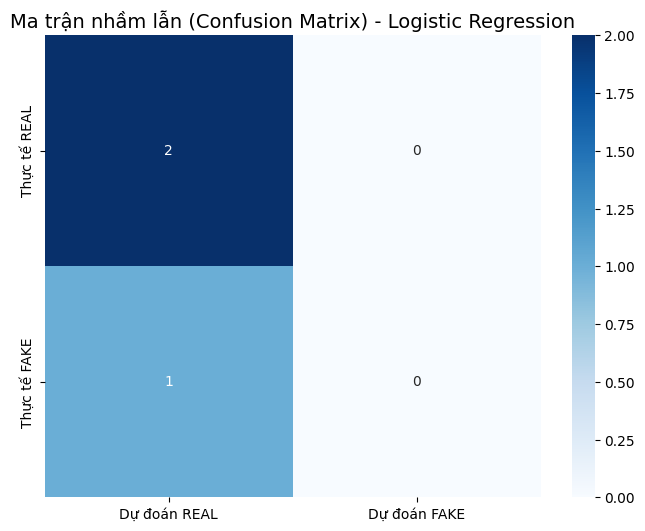

In [226]:
cm = confusion_matrix(y_test, y_pred)

# Vẽ biểu đồ trực quan hóa Ma trận nhầm lẫn
plt.figure(figsize=(8, 6)) # Thiết lập kích thước khung hình
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Dự đoán REAL', 'Dự đoán FAKE'], 
            yticklabels=['Thực tế REAL', 'Thực tế FAKE'])

plt.title('Ma trận nhầm lẫn (Confusion Matrix) - Logistic Regression', fontsize=14)
plt.show()

In [227]:
feature_name = vectorizer.get_feature_names_out() # Trích xuất từ khóa với trọng số tương ứng
weights = model.coef_[0]

coef_df = pd.DataFrame({'Từ khóa': feature_name, 'Trọng số': weights})

coef_df = coef_df.sort_values(by='Trọng số')

print("Top 5 từ khóa báo hiệu tin thật (REAL - Trọng số âm nhất):")
print(coef_df.head(5).to_string(index=False))

print("Top 5 từ khóa báo hiệu tin giả (FAKE - Trọng số dương nhất):")
print(coef_df.tail(5).sort_values(by='Trọng số', ascending=False).to_string(index=False))

Top 5 từ khóa báo hiệu tin thật (REAL - Trọng số âm nhất):
Từ khóa  Trọng số
  dự_án -0.152668
     bộ -0.118868
    thi -0.115724
    tại -0.109401
    đến -0.107955
Top 5 từ khóa báo hiệu tin giả (FAKE - Trọng số dương nhất):
    Từ khóa  Trọng số
        nói  0.161217
       rằng  0.155971
  thống_đốc  0.154100
coronavirus  0.125136
     có_thể  0.119798


In [228]:
# Test thử mô hình trên 1 câu nội dung mới
sample_news = "Sở Y tế TP.HCM cảnh báo số ca nhiễm coronavirus đang tăng cao, người dân cần đeo khẩu trang."
sample_processed = preprocess_text(sample_news)
sample_tfidf = vectorizer.transform([sample_processed])
prediction = model.predict(sample_tfidf)[0]
probability = model. predict_proba(sample_tfidf)[0][1]

print(f"Nội dung test: '{sample_news}'")
print(f"Dự đoán: {'Tin giả (FAKE)' if prediction == 1 else 'Tin thật (REAL)'}")
print(f"Xác suất là tin giả: {probability * 100:.2f}%")

Nội dung test: 'Sở Y tế TP.HCM cảnh báo số ca nhiễm coronavirus đang tăng cao, người dân cần đeo khẩu trang.'
Dự đoán: Tin thật (REAL)
Xác suất là tin giả: 47.85%


Vì 100% tin REAL đang lấy từ báo tuoitre và 100% tin FAKE đang lấy từ covid19_dataset nên nhìn vào sẽ cảm thấy mô hình đang không học cách phân biệt tin giả mà đang phân biệt báo tuổi trẻ và các văn bản về covid19.